# Project 3 — Dimensionality Reduction for Visualization and Compression

High-dimensional data is difficult to visualize and may contain redundant or noisy information. Dimensionality reduction creates a lower-dimensional representation that preserves selected structure from the original data.

The goal of this notebook is not only to draw attractive 2D plots. We will use dimensionality reduction for visualization, compression, denoising, and classification, while studying how hyperparameters change the result.

## Prerequisites

This notebook assumes basic familiarity with variance, vectors, classification metrics, and plotting. Some linear algebra intuition is useful for PCA, but the explanations are kept practical.

## Problem statement

Given 8×8 grayscale digit images represented as 64-dimensional vectors, reduce dimensionality for visualization, compression, denoising, and classification while understanding what information is preserved or lost.

In [1]:
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

In [2]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

digits = load_digits()
X = digits.data
y = digits.target
images = digits.images

print("X shape:", X.shape)
print("image shape:", images.shape)
print("classes:", np.unique(y))

X shape: (1797, 64)
image shape: (1797, 8, 8)
classes: [0 1 2 3 4 5 6 7 8 9]


## Visualizing raw samples

Each digit image is an 8×8 grid, but machine learning algorithms receive it as a 64-dimensional vector. This small image dataset is useful because it is high-dimensional enough to demonstrate dimensionality reduction, but small enough to run quickly.

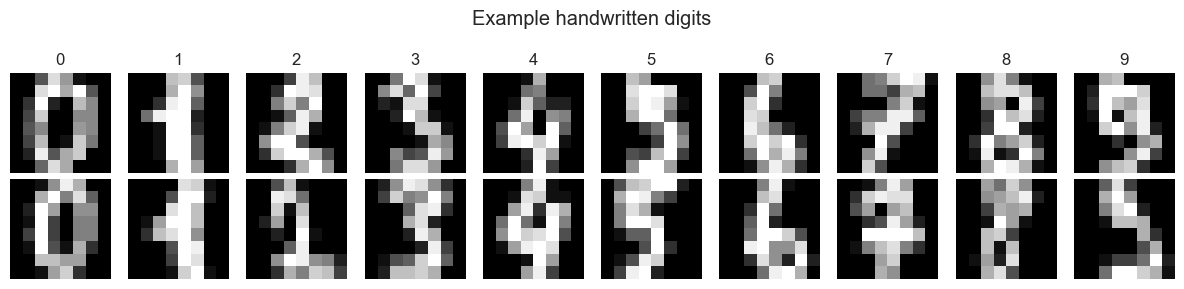

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for digit in range(10):
    idx = np.where(y == digit)[0][0]
    axes[0, digit].imshow(images[idx], cmap="gray")
    axes[0, digit].set_title(str(digit))
    axes[0, digit].axis("off")

    idx2 = np.where(y == digit)[0][1]
    axes[1, digit].imshow(images[idx2], cmap="gray")
    axes[1, digit].axis("off")

plt.suptitle("Example handwritten digits")
plt.tight_layout()
plt.show()

## Feature scaling

PCA, t-SNE, UMAP, and many classifiers are sensitive to feature scaling. The digit pixel intensities are already on a common range, but standardizing them makes PCA directions depend on standardized variation rather than raw pixel magnitude.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling:", np.round(X_scaled.mean(), 4))
print("Std after scaling:", np.round(X_scaled.std(), 4))

Mean after scaling: 0.0
Std after scaling: 0.9763


## PCA theory

Principal Component Analysis (PCA) finds new orthogonal directions that capture maximum variance in the data. The first principal component captures the largest variance direction, the second captures the largest remaining variance orthogonal to the first, and so on.

PCA is linear and unsupervised. It does not know the digit labels; it only sees variation in the feature matrix. This is why PCA may preserve high-variance structure that is not always the most discriminative for classification.

## PCA explained variance

The explained variance ratio tells us how much of the original data variation is captured by each principal component. The cumulative curve helps choose how many components are needed to preserve a target amount of variance.

80% variance    21
90% variance    31
95% variance    40
dtype: int64

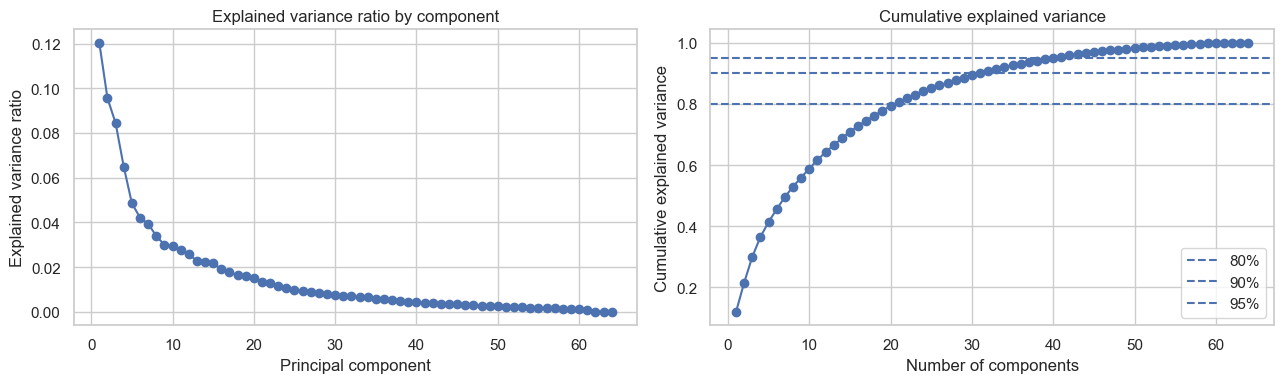

In [5]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

thresholds = [0.80, 0.90, 0.95]
components_needed = {
    f"{int(t*100)}% variance": int(np.argmax(cumulative >= t) + 1)
    for t in thresholds
}
display(pd.Series(components_needed))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, len(explained)+1), explained, marker="o")
axes[0].set_title("Explained variance ratio by component")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")

axes[1].plot(np.arange(1, len(cumulative)+1), cumulative, marker="o")
for t in thresholds:
    axes[1].axhline(t, linestyle="--", label=f"{int(t*100)}%")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()
plt.show()

### Inspecting principal components as image-like patterns

For image data, a useful way to demystify PCA is to reshape principal-component vectors back into 8×8 grids. These are not real digits. They are directions of variation: bright and dark regions show which pixels tend to increase or decrease together along that component.

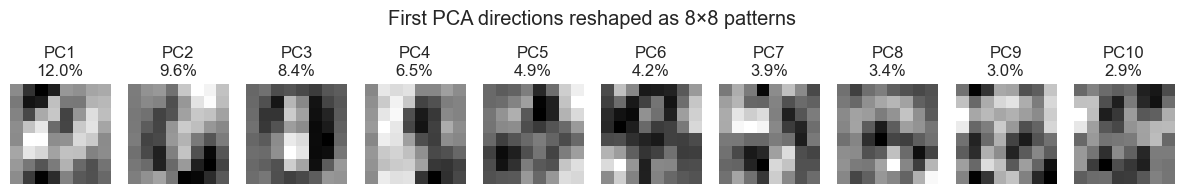

In [6]:
n_eigendigits = 10
fig, axes = plt.subplots(1, n_eigendigits, figsize=(12, 2.2))
for i, ax in enumerate(axes):
    component_img = pca_full.components_[i].reshape(8, 8)
    ax.imshow(component_img, cmap="gray")
    ax.set_title(f"PC{i+1}\n{explained[i]*100:.1f}%")
    ax.axis("off")
plt.suptitle("First PCA directions reshaped as 8×8 patterns")
plt.tight_layout()
plt.show()

High explained variance means that broad data variation is preserved. It does not guarantee optimal classification accuracy, because low-variance directions can sometimes contain class-specific details.

## PCA 2D visualization

A 2D PCA plot provides a global linear projection. It can reveal broad separation, but it should not be treated as proof of true clustering. Overlap in 2D may occur even when classes are separable in a higher-dimensional space.

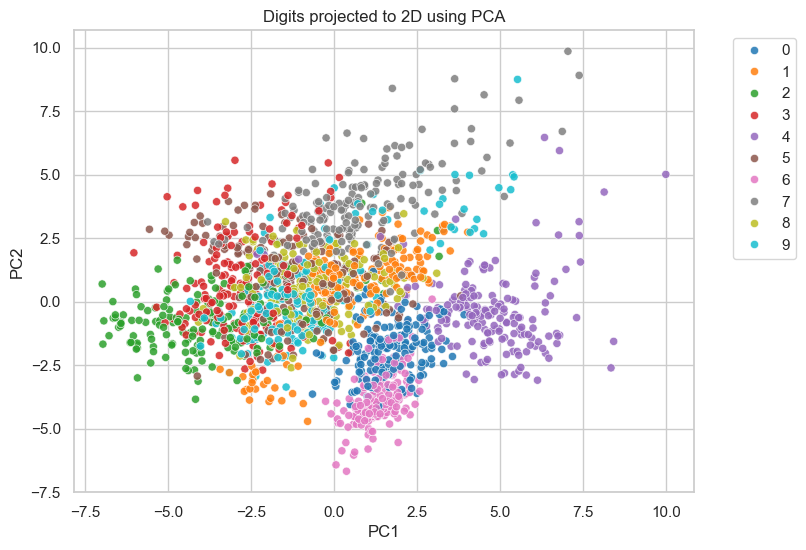

2D explained variance ratio: [0.12033916 0.09561054]


In [7]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2.fit_transform(X_scaled)

pca_plot = pd.DataFrame(X_pca2, columns=["PC1", "PC2"])
pca_plot["digit"] = y

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_plot, x="PC1", y="PC2", hue="digit", palette="tab10", s=35, alpha=0.85)
plt.title("Digits projected to 2D using PCA")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

print("2D explained variance ratio:", pca_2.explained_variance_ratio_)

## PCA compression and reconstruction

PCA can compress data by keeping only a subset of components and reconstructing the original features from that lower-dimensional representation. More components preserve more image detail, but compression becomes weaker.

,n_components,reconstruction_mse
0,2,14.054672
1,5,9.439276
2,10,6.551213
3,20,3.758133
4,30,2.069572
5,40,1.079262


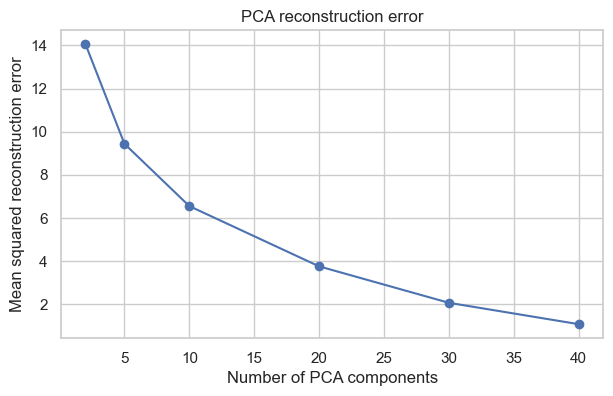

In [8]:
def reconstruct_with_pca(X_scaled, n_components):
    model = PCA(n_components=n_components, random_state=RANDOM_STATE)
    Z = model.fit_transform(X_scaled)
    X_rec_scaled = model.inverse_transform(Z)
    X_rec = scaler.inverse_transform(X_rec_scaled)
    mse = np.mean((X - X_rec) ** 2)
    return X_rec, mse

component_list = [2, 5, 10, 20, 30, 40]
recon_rows = []

for n in component_list:
    X_rec, mse = reconstruct_with_pca(X_scaled, n)
    recon_rows.append({"n_components": n, "reconstruction_mse": mse})

recon_df = pd.DataFrame(recon_rows)
display(recon_df)

plt.figure(figsize=(7, 4))
plt.plot(recon_df["n_components"], recon_df["reconstruction_mse"], marker="o")
plt.title("PCA reconstruction error")
plt.xlabel("Number of PCA components")
plt.ylabel("Mean squared reconstruction error")
plt.show()

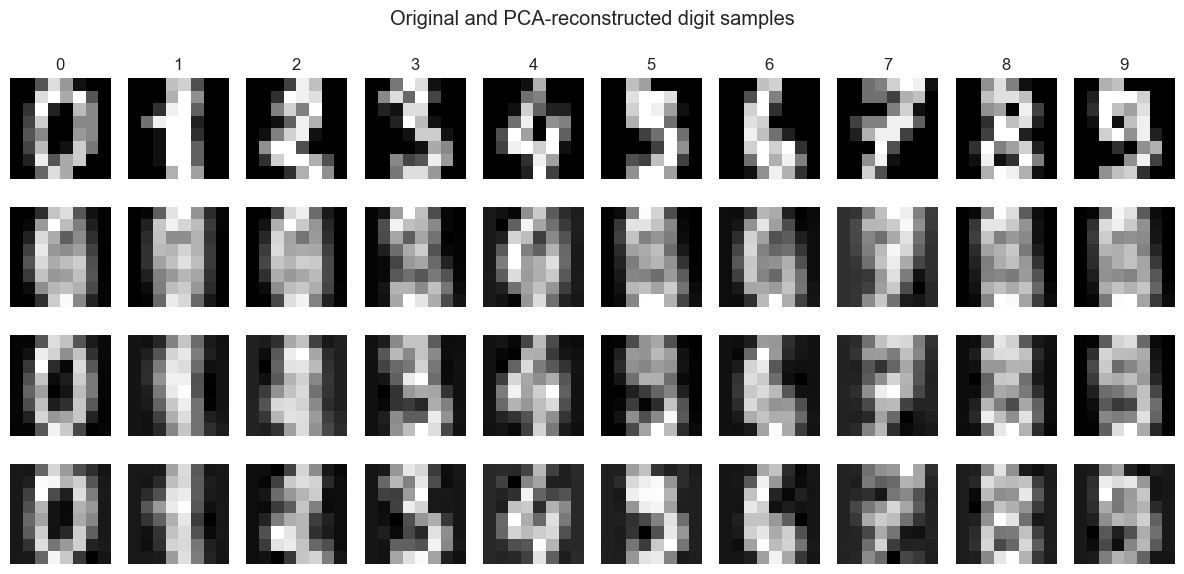

In [9]:
sample_ids = [np.where(y == d)[0][0] for d in range(10)]
chosen_components = [2, 10, 30]

fig, axes = plt.subplots(len(chosen_components)+1, 10, figsize=(12, 6))

for j, idx in enumerate(sample_ids):
    axes[0, j].imshow(X[idx].reshape(8, 8), cmap="gray")
    axes[0, j].set_title(str(y[idx]))
    axes[0, j].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)

for i, n in enumerate(chosen_components, start=1):
    X_rec, _ = reconstruct_with_pca(X_scaled, n)
    for j, idx in enumerate(sample_ids):
        axes[i, j].imshow(X_rec[idx].reshape(8, 8), cmap="gray")
        axes[i, j].axis("off")
    axes[i, 0].set_ylabel(f"{n} PCs", fontsize=10)

plt.suptitle("Original and PCA-reconstructed digit samples")
plt.tight_layout()
plt.show()

## PCA for denoising

If noise appears in directions of relatively low variance, PCA reconstruction can reduce that noise by keeping only the stronger components. This is useful but not guaranteed: PCA can also remove weak but meaningful details.

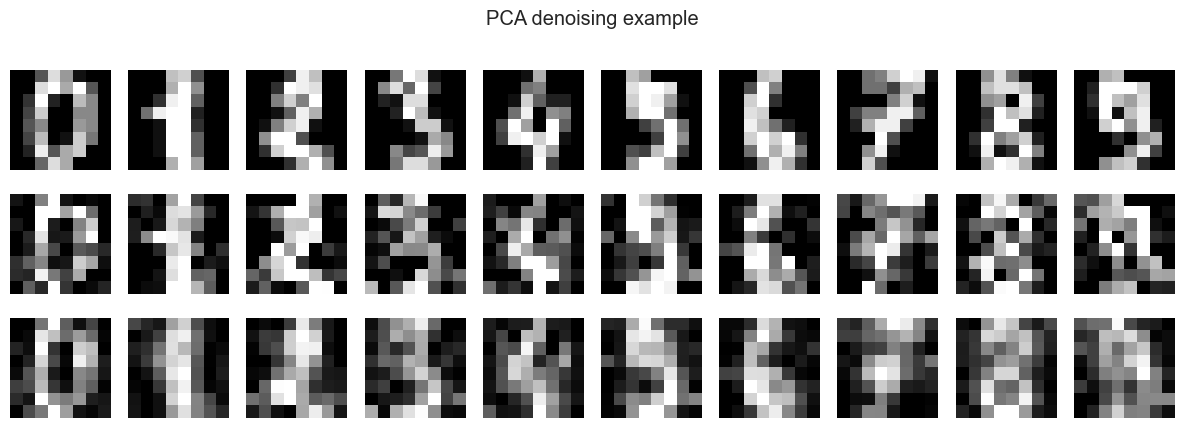

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
noise = rng.normal(0, 4.0, size=X.shape)
X_noisy = np.clip(X + noise, 0, 16)

noisy_scaler = StandardScaler()
X_noisy_scaled = noisy_scaler.fit_transform(X_noisy)

pca_denoise = PCA(n_components=30, random_state=RANDOM_STATE)
Z_noisy = pca_denoise.fit_transform(X_noisy_scaled)
X_denoised_scaled = pca_denoise.inverse_transform(Z_noisy)
X_denoised = np.clip(noisy_scaler.inverse_transform(X_denoised_scaled), 0, 16)

fig, axes = plt.subplots(3, 10, figsize=(12, 4.5))

for j, idx in enumerate(sample_ids):
    axes[0, j].imshow(X[idx].reshape(8, 8), cmap="gray")
    axes[0, j].axis("off")
    axes[1, j].imshow(X_noisy[idx].reshape(8, 8), cmap="gray")
    axes[1, j].axis("off")
    axes[2, j].imshow(X_denoised[idx].reshape(8, 8), cmap="gray")
    axes[2, j].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Noisy")
axes[2, 0].set_ylabel("PCA denoised")
plt.suptitle("PCA denoising example")
plt.tight_layout()
plt.show()

## Classification before and after PCA

Dimensionality reduction can improve, preserve, or reduce predictive performance depending on what information is discarded. We compare classification on original features against PCA-compressed features across several component counts.

Logistic Regression on original scaled features: 0.9777777777777777 0.9776428265533514


,n_components,accuracy,macro_f1
0,2,0.515556,0.498047
1,5,0.784444,0.779976
2,10,0.862222,0.860433
3,20,0.942222,0.942087
4,30,0.948889,0.948740
5,40,0.960000,0.959854
6,50,0.977778,0.977661
7,64,0.977778,0.977643


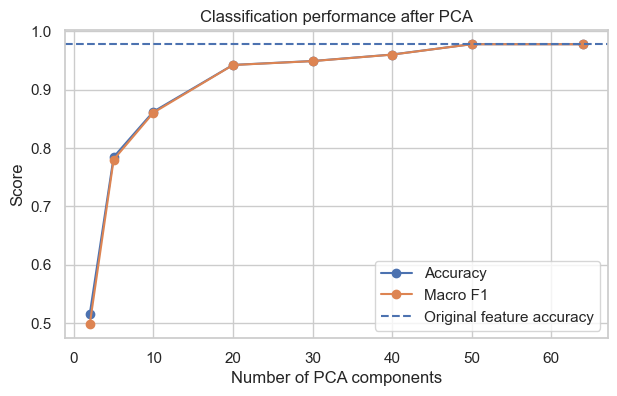

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

def evaluate_classifier(Xtr, Xte, model_name="logistic"):
    if model_name == "logistic":
        clf = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
    elif model_name == "rf":
        clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    return accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")

baseline_acc, baseline_f1 = evaluate_classifier(X_train, X_test, "logistic")
print("Logistic Regression on original scaled features:", baseline_acc, baseline_f1)

rows = []
for n in [2, 5, 10, 20, 30, 40, 50, 64]:
    pca_model = PCA(n_components=n, random_state=RANDOM_STATE)
    Xtr_pca = pca_model.fit_transform(X_train)
    Xte_pca = pca_model.transform(X_test)
    acc, f1 = evaluate_classifier(Xtr_pca, Xte_pca, "logistic")
    rows.append({"n_components": n, "accuracy": acc, "macro_f1": f1})

clf_df = pd.DataFrame(rows)
display(clf_df)

plt.figure(figsize=(7, 4))
plt.plot(clf_df["n_components"], clf_df["accuracy"], marker="o", label="Accuracy")
plt.plot(clf_df["n_components"], clf_df["macro_f1"], marker="o", label="Macro F1")
plt.axhline(baseline_acc, linestyle="--", label="Original feature accuracy")
plt.title("Classification performance after PCA")
plt.xlabel("Number of PCA components")
plt.ylabel("Score")
plt.legend()
plt.show()

### Joint view: variance retained, reconstruction, and classification

PCA can be used for several objectives, but the best number of components need not be the same for all of them. The next table combines cumulative variance, reconstruction error, and classification performance for the tested component counts. This is more analytical than looking at one plot at a time because it shows the trade-off between compression and task performance.

,n_components,cumulative_variance,reconstruction_mse,classification_accuracy,classification_macro_f1
0,2,0.2159,14.0547,0.5156,0.4980
1,5,0.4140,9.4393,0.7844,0.7800
2,10,0.5887,6.5512,0.8622,0.8604
3,20,0.7931,3.7581,0.9422,0.9421
4,30,0.8932,2.0696,0.9489,0.9487
5,40,0.9508,1.0793,0.9600,0.9599


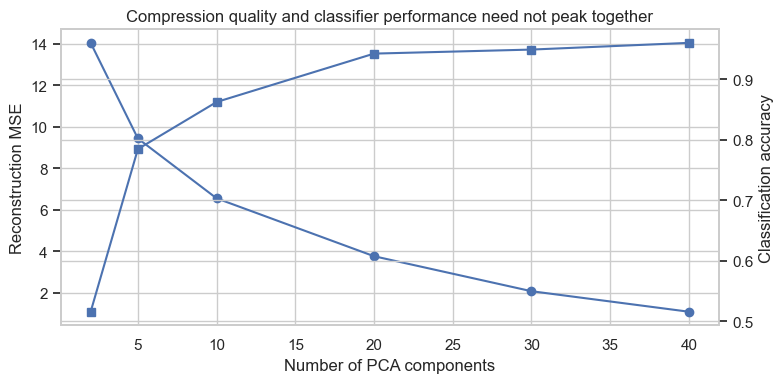

In [12]:
objective_rows = []
for n in component_list:
    cum_var = cumulative[n-1]
    rec_error = recon_df.loc[recon_df["n_components"] == n, "reconstruction_mse"].iloc[0]
    if n in set(clf_df["n_components"]):
        row = clf_df.loc[clf_df["n_components"] == n].iloc[0]
        objective_rows.append({
            "n_components": n,
            "cumulative_variance": cum_var,
            "reconstruction_mse": rec_error,
            "classification_accuracy": row["accuracy"],
            "classification_macro_f1": row["macro_f1"]
        })

objective_df = pd.DataFrame(objective_rows)
display(objective_df.round(4))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(objective_df["n_components"], objective_df["reconstruction_mse"], marker="o", label="Reconstruction MSE")
ax1.set_xlabel("Number of PCA components")
ax1.set_ylabel("Reconstruction MSE")
ax2 = ax1.twinx()
ax2.plot(objective_df["n_components"], objective_df["classification_accuracy"], marker="s", label="Accuracy")
ax2.set_ylabel("Classification accuracy")
plt.title("Compression quality and classifier performance need not peak together")
fig.tight_layout()
plt.show()

## t-SNE theory

t-SNE is a nonlinear visualization method that tries to preserve local neighborhood relationships. It is often useful for creating 2D maps of high-dimensional data, but it is not mainly a compression method or a general-purpose feature transformer for downstream modeling.

Important caution: distances between far-apart clusters, cluster sizes, and empty spaces in t-SNE plots should not be overinterpreted.

## t-SNE hyperparameter effects

`perplexity` controls the neighborhood scale. Small perplexity emphasizes very local structure; larger perplexity considers broader neighborhoods. Learning rate and random seed can also change the embedding.

### Quantifying local-neighborhood preservation

Visual inspection is necessary for embeddings, but it can be misleading. The trustworthiness score measures how well local neighborhoods in the low-dimensional embedding agree with neighborhoods in the original space. It does not say whether the plot is semantically correct, but it gives a useful quantitative companion to the figures.

,method,setting,trustworthiness_10
0,PCA-2D,n_components=2,0.8163
1,t-SNE,perplexity=5,0.9819
2,t-SNE,perplexity=15,0.9853
3,t-SNE,perplexity=30,0.9863
4,t-SNE,perplexity=50,0.9858


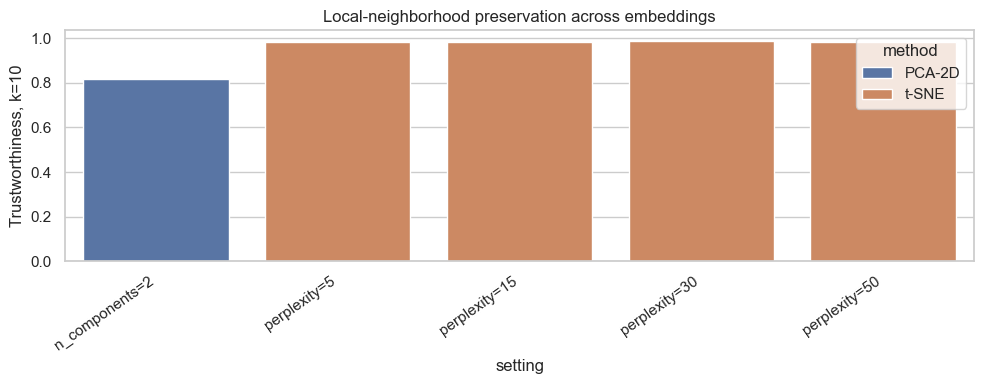

In [13]:
from sklearn.manifold import trustworthiness

trust_rows = []
trust_rows.append({
    "method": "PCA-2D",
    "setting": "n_components=2",
    "trustworthiness_10": trustworthiness(X_scaled, X_pca2, n_neighbors=10)
})

for perplexity in [5, 15, 30, 50]:
    emb = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_STATE
    ).fit_transform(X_scaled)
    trust_rows.append({
        "method": "t-SNE",
        "setting": f"perplexity={perplexity}",
        "trustworthiness_10": trustworthiness(X_scaled, emb, n_neighbors=10)
    })

try:
    import umap
    for n_neighbors in [5, 15, 50]:
        emb = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=0.1, random_state=RANDOM_STATE).fit_transform(X_scaled)
        trust_rows.append({
            "method": "UMAP",
            "setting": f"n_neighbors={n_neighbors}, min_dist=0.1",
            "trustworthiness_10": trustworthiness(X_scaled, emb, n_neighbors=10)
        })
except ImportError:
    pass

trust_df = pd.DataFrame(trust_rows)
display(trust_df.round(4))

plt.figure(figsize=(10, 4))
sns.barplot(data=trust_df, x="setting", y="trustworthiness_10", hue="method")
plt.xticks(rotation=35, ha="right")
plt.title("Local-neighborhood preservation across embeddings")
plt.ylabel("Trustworthiness, k=10")
plt.tight_layout()
plt.show()

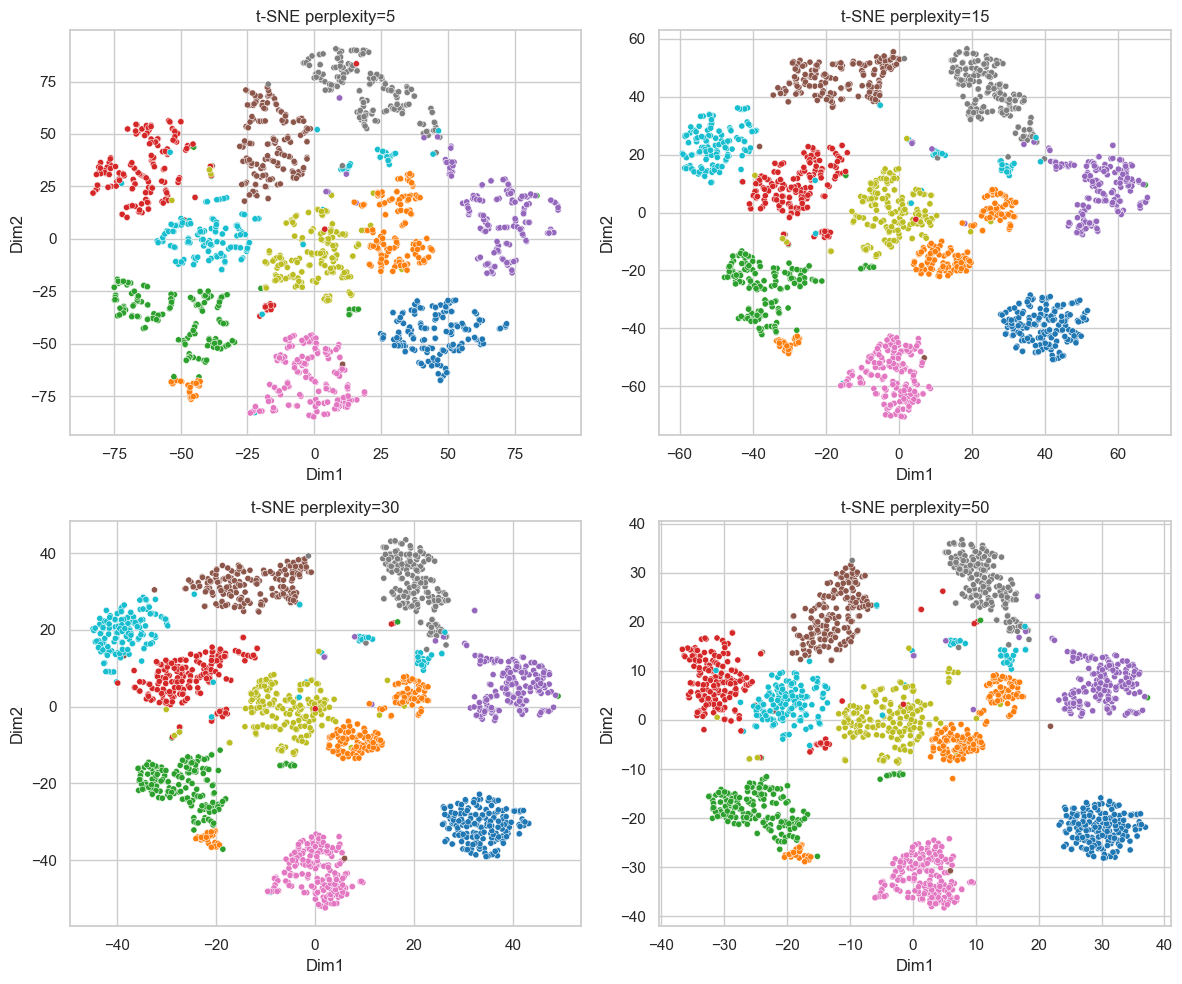

In [14]:
tsne_settings = [
    {"perplexity": 5, "learning_rate": "auto", "random_state": 42},
    {"perplexity": 15, "learning_rate": "auto", "random_state": 42},
    {"perplexity": 30, "learning_rate": "auto", "random_state": 42},
    {"perplexity": 50, "learning_rate": "auto", "random_state": 42},
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, params in zip(axes, tsne_settings):
    emb = TSNE(
        n_components=2,
        perplexity=params["perplexity"],
        learning_rate=params["learning_rate"],
        init="pca",
        random_state=params["random_state"]
    ).fit_transform(X_scaled)
    tmp = pd.DataFrame(emb, columns=["Dim1", "Dim2"])
    tmp["digit"] = y
    sns.scatterplot(data=tmp, x="Dim1", y="Dim2", hue="digit", palette="tab10", s=20, legend=False, ax=ax)
    ax.set_title(f"t-SNE perplexity={params['perplexity']}")

plt.tight_layout()
plt.show()

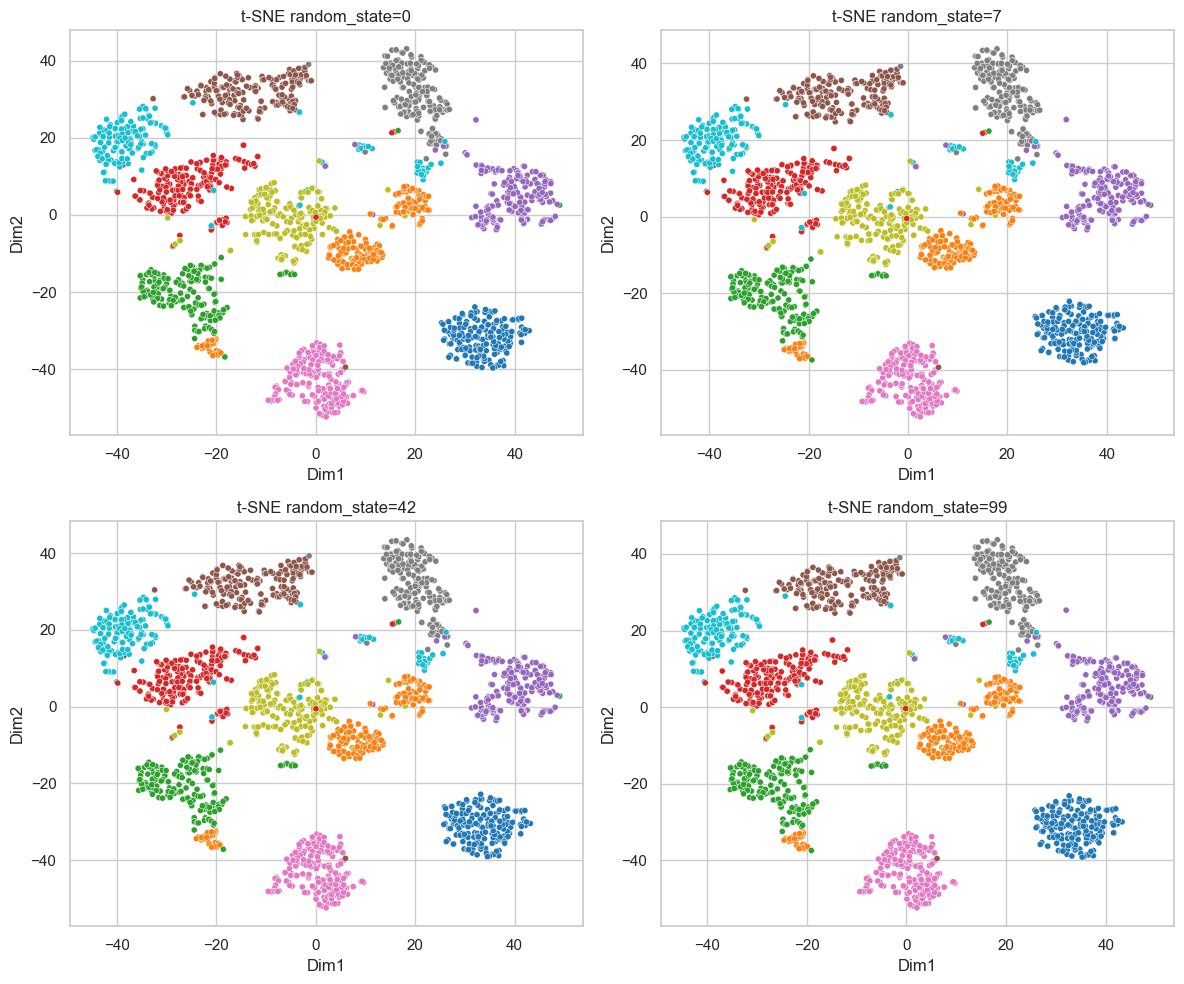

In [15]:
tsne_seed_settings = [0, 7, 42, 99]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, seed in zip(axes, tsne_seed_settings):
    emb = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=seed
    ).fit_transform(X_scaled)
    tmp = pd.DataFrame(emb, columns=["Dim1", "Dim2"])
    tmp["digit"] = y
    sns.scatterplot(data=tmp, x="Dim1", y="Dim2", hue="digit", palette="tab10", s=20, legend=False, ax=ax)
    ax.set_title(f"t-SNE random_state={seed}")

plt.tight_layout()
plt.show()

## UMAP theory

UMAP is another nonlinear dimensionality reduction method. It often preserves more global structure than t-SNE and can transform new samples after fitting. It is widely used for visualization and exploratory analysis.

If `umap-learn` is not installed, run the commented installation cell below or skip the UMAP section.

In [16]:
# Optional installation if needed:
# !pip install umap-learn

In [17]:
try:
    import umap

    umap_settings = [
        {"n_neighbors": 5, "min_dist": 0.1},
        {"n_neighbors": 15, "min_dist": 0.1},
        {"n_neighbors": 50, "min_dist": 0.1},
        {"n_neighbors": 15, "min_dist": 0.0},
        {"n_neighbors": 15, "min_dist": 0.5},
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    for ax, params in zip(axes, umap_settings):
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=params["n_neighbors"],
            min_dist=params["min_dist"],
            random_state=RANDOM_STATE
        )
        emb = reducer.fit_transform(X_scaled)
        tmp = pd.DataFrame(emb, columns=["Dim1", "Dim2"])
        tmp["digit"] = y
        sns.scatterplot(data=tmp, x="Dim1", y="Dim2", hue="digit", palette="tab10", s=20, legend=False, ax=ax)
        ax.set_title(f"UMAP n_neighbors={params['n_neighbors']}, min_dist={params['min_dist']}")

    for j in range(len(umap_settings), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
except ImportError:
    print("umap-learn is not installed. Install it with: pip install umap-learn")

umap-learn is not installed. Install it with: pip install umap-learn


`n_neighbors` controls the balance between local and global structure. Smaller values focus on close neighborhoods; larger values include broader relationships. `min_dist` controls how tightly points are packed in the embedding.

## Comparing PCA, t-SNE, and UMAP

In [18]:
comparison = pd.DataFrame([
    {
        "Method": "PCA",
        "Linear/nonlinear": "Linear",
        "Main use": "Compression, denoising, variance analysis, visualization",
        "Can transform new samples?": "Yes",
        "Preserves": "Global variance directions",
        "Key hyperparameters": "n_components",
        "Main risks": "May miss nonlinear structure; high variance need not equal class relevance"
    },
    {
        "Method": "t-SNE",
        "Linear/nonlinear": "Nonlinear",
        "Main use": "2D/3D visualization",
        "Can transform new samples?": "Not in standard sklearn implementation",
        "Preserves": "Local neighborhoods",
        "Key hyperparameters": "perplexity, learning_rate, random_state",
        "Main risks": "Distances and cluster sizes can be misleading"
    },
    {
        "Method": "UMAP",
        "Linear/nonlinear": "Nonlinear",
        "Main use": "Visualization and nonlinear embeddings",
        "Can transform new samples?": "Yes, after fitting",
        "Preserves": "Local structure with some global organization",
        "Key hyperparameters": "n_neighbors, min_dist, n_components",
        "Main risks": "Embeddings depend strongly on hyperparameters"
    }
])
comparison

,Method,Linear/nonlinear,Main use,Can transform new samples?,Preserves,Key hyperparameters,Main risks
0,PCA,Linear,"Compression, denoising, variance analysis, vis...",Yes,Global variance directions,n_components,May miss nonlinear structure; high variance ne...
1,t-SNE,Nonlinear,2D/3D visualization,Not in standard sklearn implementation,Local neighborhoods,"perplexity, learning_rate, random_state",Distances and cluster sizes can be misleading
2,UMAP,Nonlinear,Visualization and nonlinear embeddings,"Yes, after fitting",Local structure with some global organization,"n_neighbors, min_dist, n_components",Embeddings depend strongly on hyperparameters


## Visualization pitfalls

Two-dimensional plots are projections. They can reveal structure, but they can also exaggerate separation. In t-SNE and UMAP, visually separated islands do not automatically prove true clusters. Distances, areas, and cluster sizes may not have the same meaning as in the original feature space.

Use visualization together with quantitative evaluation and domain understanding.

## Limitations

The Digits dataset is small and clean compared with many real image, text, gene-expression, or hyperspectral datasets. PCA is linear. t-SNE and UMAP are sensitive to hyperparameters and random initialization. Dimensionality reduction may remove useful information if the objective is prediction rather than visualization or compression.

## What we learned

PCA is useful for compression, denoising, and variance analysis. t-SNE and UMAP are mainly visualization tools. Hyperparameters strongly affect embeddings. Lower dimensionality is not automatically better; evaluation depends on whether the objective is visualization, compression, denoising, or prediction.

## Possible extensions

Extensions include kernel PCA, autoencoder compression, supervised dimensionality reduction, UMAP before clustering, high-dimensional gene expression data, and hyperspectral dimensionality reduction.